In [1]:
from langgraph.graph import StateGraph,END,START
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel,Field
from typing import Literal,TypedDict
from dotenv import load_dotenv

In [2]:
class Review(TypedDict):
    user_review: str
    sentiment: Literal["positive","negative"] =Field(description="The sentiment should be positive or negative")
    postive_s:str
    negative_s: str

In [3]:
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [4]:
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
def sentiment(state:Review):
    prompt=f"analysis the user review \n {state['user_review']} and provide the only sentiment is positive or negative"
    respone=llm.invoke(prompt).content.lower()
    return {"sentiment":respone}

In [6]:
def check_condition(state: Review) -> Literal["positive_sentiment","negative_sentiment"]:
    if state["sentiment"]=="positive":
        return "positive_sentiment"
    else:
        return "negative_sentiment"

In [7]:
def positive_sentiment(state:Review):
    prompt=f"Write a positive feedback base on the state['user_review'] in formal english"
    response=llm.invoke(prompt).content
    return {"postive_s":response}

In [8]:
def negative_sentiment(state:Review):
    prompt=f"Write a apologise feedback base on the state['user_review'] in formal english"
    response=llm.invoke(prompt).content
    return {"negative_s":response}

In [12]:
graph=StateGraph(Review)

In [13]:
graph.add_node("sentiment",sentiment)
graph.add_node("positive_sentiment",positive_sentiment)
graph.add_node("negative_sentiment",negative_sentiment)

graph.add_edge(START,"sentiment")
graph.add_conditional_edges("sentiment",check_condition)
graph.add_edge("positive_sentiment",END)
graph.add_edge("negative_sentiment",END)

workflow=graph.compile()

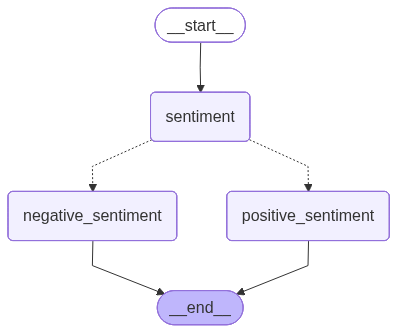

In [14]:
workflow

In [15]:
result=workflow.invoke({"user_review": "The Software is very very good"})

In [16]:
result

{'user_review': 'The Software is very very good',
 'sentiment': 'based on the user review: "the software is very very good"\n\n**sentiment:**\n\nthe sentiment is **highly positive**.\n\n**analysis:**\n\n*   **core sentiment:** the word "good" is an unequivocally positive descriptor.\n*   **intensification:** the repetition of "very very" acts as a strong intensifier. it suggests that the user isn\'t just satisfied, but genuinely impressed or highly pleased with the software. it conveys enthusiasm and a high degree of approval.\n*   **lack of specificity:** while the sentiment is clear and strong, the review lacks any specific details about *why* the software is so good. it doesn\'t mention features, performance, ease of use, customer support, or any other particular aspect. this means while the overall feeling is excellent, there are no actionable insights for developers or specific selling points for other potential users to understand *what* makes it great.\n*   **conciseness:** it\'